# 6. Topic modeling with MALLET

What is podcasting *about*? Categories give a coarse answer — someone chose
"Society & Culture" from a dropdown once. Topic modeling gives a bottom-up
answer, derived from what people actually say.

This notebook fits an LDA model with **MALLET**, which remains the reference
implementation for Gibbs-sampled LDA and usually gives more coherent topics than
the common Python alternatives. It runs on the JVM, so we drive it through
`little-mallet-wrapper`.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
# Report the location relative to here, so the printed output does not embed
# whoever's home directory this happened to be built in.
print("sporc", sporc.__version__, "from",
      os.path.relpath(os.path.dirname(sporc.__file__)))


sporc 1.1.0 from ../../sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md. Kept
# relative so nothing machine-specific leaks into the logged path.
SUBSET = "../../subsets/tutorial"
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from ../../subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache ../../subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.05s  (403 podcasts, 2,967 episodes)


SPORCDataset(parquet, 403 podcasts, 2967 episodes)


## 6.1 Pointing at MALLET

`little_mallet_wrapper` shells out to the `mallet` binary, so it needs MALLET on
disk and a working Java. Rather than hard-code a path, we resolve it from the
environment: set the **`MALLET_PATH`** environment variable to your MALLET
install's `bin/mallet`, or put `mallet` on your `PATH`. Java is found the same
way (`PATH`, or a `JAVA_HOME`).


In [3]:
import os, shutil, subprocess

# Resolve MALLET from the environment, never a fixed path: the MALLET_PATH env
# var if set, otherwise a `mallet` on PATH.
MALLET_PATH = os.environ.get("MALLET_PATH") or shutil.which("mallet")

if not MALLET_PATH or not os.path.exists(MALLET_PATH):
    raise SystemExit(
        "MALLET not found. Download it from https://mimno.github.io/Mallet/, "
        "then set the MALLET_PATH environment variable to its bin/mallet, or "
        "put `mallet` on your PATH."
    )

java = shutil.which("java")
if not java:
    raise SystemExit("Java not found on PATH -- MALLET runs on the JVM.")

# Print how each was resolved, not an absolute path, so this notebook's output
# stays free of machine-specific locations.
print("mallet : resolved from", "MALLET_PATH" if os.environ.get("MALLET_PATH") else "PATH")
print("java   :", subprocess.run([java, "-version"], capture_output=True,
                                  text=True).stderr.splitlines()[0])


mallet : resolved from MALLET_PATH


java   : openjdk version "11.0.27" 2025-04-15


## 6.2 Choosing the document unit

This is the modelling decision that matters most, and it is easy to make
thoughtlessly.

* **One document = one episode.** Few, long documents. LDA sees a whole
  wide-ranging conversation as one bag of words and returns mush.
* **One document = one turn.** Many, tiny documents. Most turns are a sentence;
  there is no co-occurrence to learn from.
* **One document = a window of turns.** A chunk of conversation that stays on
  roughly one thing. This is what `Episode.sliding_window()` is for.

We use windows. It is also a nice demonstration of the sliding-window API.


In [4]:
import little_mallet_wrapper as lmw
import pandas as pd

import random

# All 2,421 diarized episodes give ~4.1M tokens, which MALLET fits in ~20
# minutes -- too slow to sit and watch. 600 episodes still yields thousands of
# windows and readable topics. Raise it (or set None) for a real run.
N_EPISODES = 600

eps = [e for e in sporc.iterate_episodes() if e.has_turn_data]
print(f"diarized episodes: {len(eps):,}")

if N_EPISODES and len(eps) > N_EPISODES:
    eps.sort(key=lambda e: (e.podcast_title, e.title))
    eps = random.Random(0).sample(eps, N_EPISODES)
    print(f"sampled          : {len(eps):,}")

docs, meta = [], []
for e in eps:
    if e.turn_count < 12:
        continue
    for win in e.sliding_window(window_size=12, overlap=3):
        text = win.get_text()
        if len(text.split()) < 120:      # too short to carry a topic
            continue
        docs.append(text)
        # episode_id, not title: titles repeat (one podcast here has seven
        # episodes called "Daily Encouragement"), so grouping by title would
        # merge distinct episodes. Keep the title alongside for reading.
        meta.append({"episode_id": e.episode_id, "episode": e.title,
                     "podcast_id": e.podcast_id, "podcast": e.podcast_title,
                     "category": e.primary_category,
                     "date": e.episode_date,
                     "start": win.time_range[0]})

print(f"windows (documents): {len(docs):,}")
print(f"median words/doc   : {int(pd.Series([len(d.split()) for d in docs]).median())}"
      if docs else "")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


diarized episodes: 2,967
sampled          : 600


windows (documents): 6,145


median words/doc   : 366


In [5]:
# lmw's default processing lowercases, strips punctuation and short words.
# Podcast-specific stopwords matter: without them every topic is "like/know/yeah".
EXTRA_STOP = {
    "like", "know", "yeah", "just", "really", "think", "going", "right",
    "gonna", "okay", "kind", "sort", "actually", "want", "said", "say",
    "thing", "things", "people", "time", "lot", "way", "good", "little",
    "podcast", "episode", "welcome", "today", "talk", "talking", "guys",
    "come", "look", "make", "need", "let", "does", "did", "got", "get",
}

processed = [lmw.process_string(d, numbers="remove") for d in docs]
processed = [" ".join(w for w in d.split() if w not in EXTRA_STOP) for d in processed]
processed = [d for d in processed if len(d.split()) >= 60]

print(f"documents after cleaning: {len(processed):,}")
print(f"\nexample:\n  {processed[0][:220]}...")


documents after cleaning: 5,117

example:
  music everyone pov crypto bitcoiners ethereum listened david hoffman buddy christian christian man excited show friend pod great bitcoiner guy swan stability even exists guy pretty man fantastic fantastic guy give bit pl...


## 6.3 Fitting

`train_topic_model` writes MALLET's inputs to a directory, shells out, and reads
the results back. On a few thousand documents this takes a minute or two.


In [6]:
import tempfile, os

NUM_TOPICS = 15
outdir = tempfile.mkdtemp(prefix="sporc_lda_")
print("working dir:", outdir)

# Plain strings, not pathlib.Path: little_mallet_wrapper builds its shell
# command by string concatenation and raises TypeError on a PosixPath.
path_to_training_data       = os.path.join(outdir, "training.txt")
path_to_formatted_training  = os.path.join(outdir, "mallet.training")
path_to_model               = os.path.join(outdir, f"mallet.model.{NUM_TOPICS}")
path_to_topic_keys          = os.path.join(outdir, f"mallet.topic_keys.{NUM_TOPICS}")
path_to_topic_distributions = os.path.join(outdir, f"mallet.topic_distributions.{NUM_TOPICS}")
path_to_word_weights        = os.path.join(outdir, f"mallet.word_weights.{NUM_TOPICS}")
path_to_diagnostics         = os.path.join(outdir, f"mallet.diagnostics.{NUM_TOPICS}.xml")

lmw.import_data(MALLET_PATH, path_to_training_data, path_to_formatted_training,
                processed)
# train_topic_model's signature varies across little-mallet-wrapper releases:
# word_weights/diagnostics are required positionally here, and num_topics is
# positional too. Check inspect.signature(lmw.train_topic_model) if this raises.
lmw.train_topic_model(MALLET_PATH, path_to_formatted_training, path_to_model,
                      path_to_topic_keys, path_to_topic_distributions,
                      path_to_word_weights, path_to_diagnostics,
                      NUM_TOPICS)

topics = lmw.load_topic_keys(path_to_topic_keys)
dists = lmw.load_topic_distributions(path_to_topic_distributions)
print(f"\nfitted {len(topics)} topics over {len(dists)} documents")


working dir: /tmp/sporc_lda_0ri_o_o9
Importing data...


Complete
Training topic model...


Mallet LDA: 15 topics, 4 topic bits, 1111 topic mask


Data loaded.


max tokens: 2218
total tokens: 1040773


...

[beta: 0.03443] 
<980> LL/token: -8.57668


[beta: 0.03449] 
<990> LL/token: -8.57717



0	0.06303	fucking body day life matt training shit fuck energy much morning coach dude every man jason self night gym feel 
1	1.23284	one would mean something well back even see could take always day work every put stuff maybe two feel much 
2	0.06341	practice insurance dental business tax pay able work back law two one practices network company patients patient plan take mark 
3	0.06204	food well world restaurant airlines one airline chinese country china project united american new different tucson meat countries states first 
4	0.11727	one music car went back day didn man bike guy mean put called house play use three band around first 
5	0.05737	money save fed would bank debt policy financial credit monetary inflation interest loan mortgage economy banks federal act treasury one 
6	0.25783	school didn years started wanted would went life first back year work always college family kids wasn different job came 
7	0.19236	new covid back still well year industry see last seeing around 

[beta: 0.03436] 
<1000> LL/token: -8.57692

Total time: 5 minutes 27 seconds


Complete

fitted 15 topics over 5117 documents


In [7]:
for i, words in enumerate(topics):
    print(f"topic {i:2d}: {' '.join(words[:10])}")


topic  0: fucking day life body matt shit training fuck much energy
topic  1: one would mean something well back even see take could
topic  2: practice insurance business dental pay tax two one work back
topic  3: food well world restaurant airlines airline new one project chinese
topic  4: one music car day back didn went man guy bike
topic  5: money save fed would bank debt policy financial credit monetary
topic  6: school years didn started wanted would went life first year
topic  7: new covid back still well see industry year seeing last
topic  8: business well work company one team also different working companies
topic  9: black women feel life also white person world important see
topic 10: money market estate real property sell buy million stock deal
topic 11: content something marketing brand video days social linkedin media jumping
topic 12: health care public covid patients patient safety virus also one
topic 13: sales product customer data process customers problem one use 

## 6.4 Naming the topics

Top words are a prompt, not a label. Read them, read a couple of the documents
that load highest, and name the topic yourself. Automatic labels are how topic
models get over-interpreted.


In [8]:
import numpy as np

D = np.array(dists)
print("Highest-loading document for a few topics:\n")
for t in range(min(4, NUM_TOPICS)):
    j = int(D[:, t].argmax())
    print(f"topic {t} ({' '.join(topics[t][:6])})")
    print(f"   {meta[j]['podcast'][:44]!r} — {meta[j]['category']}")
    print(f"   {processed[j][:170]}...\n")


Highest-loading document for a few topics:



topic 0 (fucking day life body matt shit)
   'Grow or Die Podcast' — education
   growth hormone take hear importance growth hormone posts workout clear listeners belief system first foremost far growth hormone concerned important consistency within us...

topic 1 (one would mean something well back)
   'Business Growth Show - B2B Marketing & Deman' — business
   hello saying tell happier unhappy eyes see smile looking frowning gross remind day could tell lady wasn wasn smile somebody something smile looks big grin face felt bette...

topic 2 (practice insurance business dental pay tax)
   'Hustle & Flow with Heather Hubbard' — business
   power large delta company engage negotiations metlife second company negotiate directly metlife many third party partners phenomenal fees metlife top phenomenal fees doll...

topic 3 (food well world restaurant airlines airline)
   'Nonstop Nonprofit' — business
   try decide menu seemed easier cook knew invented idea cuisine called hong kong cuisine

## 6.5 Topic prevalence by category

Do the bottom-up topics line up with the top-down categories? Where they diverge
is usually the interesting part.


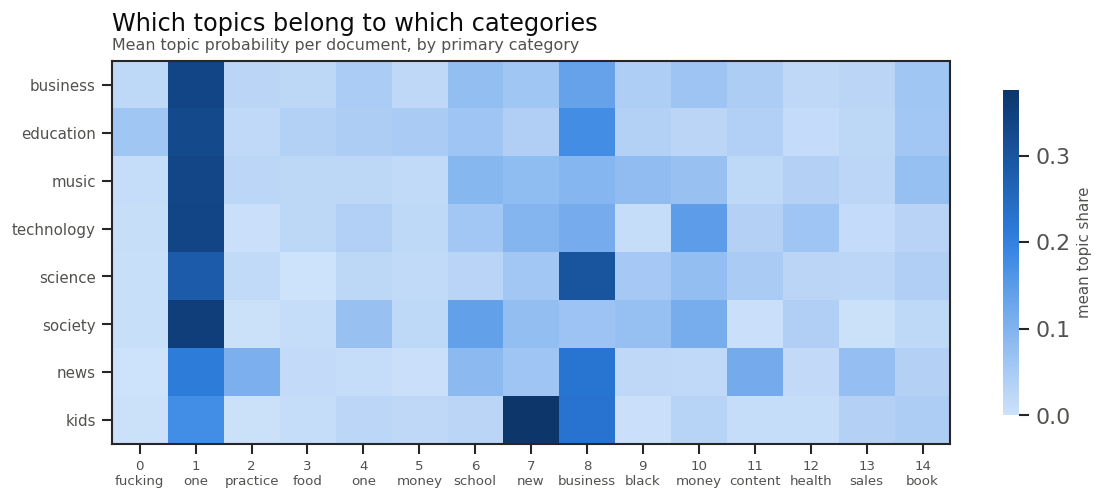

In [9]:
import matplotlib.pyplot as plt
from _viz import sequential_cmap

m = pd.DataFrame(meta[:len(D)])
m = m.assign(**{f"t{i}": D[:, i] for i in range(NUM_TOPICS)})

top_cats = m.category.value_counts().head(8).index.tolist()
mat = (m[m.category.isin(top_cats)]
         .groupby("category")[[f"t{i}" for i in range(NUM_TOPICS)]].mean()
         .loc[top_cats])

fig, ax = plt.subplots(figsize=(10, 4.4))
im = ax.imshow(mat.values, aspect="auto", cmap=sequential_cmap(), vmin=0)
ax.set_xticks(range(NUM_TOPICS))
ax.set_xticklabels([f"{i}\n{topics[i][0][:9]}" for i in range(NUM_TOPICS)],
                   fontsize=8)
ax.set_yticks(range(len(mat)))
ax.set_yticklabels(mat.index, fontsize=9)
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.85)
cb.set_label("mean topic share", fontsize=9, color=INK_SECONDARY)
cb.outline.set_visible(False)
finish(ax, title="Which topics belong to which categories",
       subtitle="Mean topic probability per document, by primary category")
plt.show()


In [10]:
# The most category-distinctive topic: highest share relative to its own mean.
rel = mat / mat.mean(axis=0)
for cat in mat.index:
    t = int(rel.loc[cat].values.argmax())
    print(f"  {cat:26s} -> topic {t:2d}  ({' '.join(topics[t][:6])})")


  business                   -> topic  0  (fucking day life body matt shit)
  education                  -> topic  0  (fucking day life body matt shit)
  music                      -> topic  9  (black women feel life also white)
  technology                 -> topic 12  (health care public covid patients patient)
  science                    -> topic  8  (business well work company one team)
  society                    -> topic  4  (one music car day back didn)
  news                       -> topic  2  (practice insurance business dental pay tax)
  kids                       -> topic  7  (new covid back still well see)


## 6.6 Caveats

* **k is a choice, not a finding.** 15 topics because we said 15. Fit several
  values and look at them; there is no "correct" k, and coherence metrics only
  narrow the field.
* **Stopwords shape the result.** The `EXTRA_STOP` list above is doing real work:
  without it, conversational filler dominates every topic. That list is a
  researcher decision and belongs in your write-up.
* **Windows overlap.** `overlap=3` means adjacent documents share turns, so
  documents are not independent. Fine for description, wrong for anything
  inferential.
* **Ads.** Podcast transcripts are full of read advertising, which forms tight,
  high-coherence topics that are about the ad market rather than the show.
* **Two months, 65% coverage.** As everywhere in SPoRC.
